In [261]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

In [262]:
df = pd.read_csv("./data/CPI_PPI_All_Commodity.csv")
df

,DATE,CPIAUCSL_NBD19470101,PPIACO_NBD19470101
0,1913-01-01,.,49.38776
1,1913-02-01,.,48.97959
2,1913-03-01,.,48.97959
3,1913-04-01,.,48.97959
4,1913-05-01,.,48.57143
...,...,...,...
1332,2024-01-01,1441.73650,1025.73878
1333,2024-02-01,1448.10987,1040.46531
1334,2024-03-01,1453.58473,1041.28980
1335,2024-04-01,1458.13315,1049.60408


In [263]:
df_mod = df.copy()
df_mod.head()

,DATE,CPIAUCSL_NBD19470101,PPIACO_NBD19470101
0,1913-01-01,.,49.38776
1,1913-02-01,.,48.97959
2,1913-03-01,.,48.97959
3,1913-04-01,.,48.97959
4,1913-05-01,.,48.57143


In [264]:
df.head()

,DATE,CPIAUCSL_NBD19470101,PPIACO_NBD19470101
0,1913-01-01,.,49.38776
1,1913-02-01,.,48.97959
2,1913-03-01,.,48.97959
3,1913-04-01,.,48.97959
4,1913-05-01,.,48.57143


In [265]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   DATE                  1337 non-null   object 
 1   CPIAUCSL_NBD19470101  1337 non-null   object 
 2   PPIACO_NBD19470101    1337 non-null   float64
dtypes: float64(1), object(2)
memory usage: 31.5+ KB


In [266]:
# rename the columns of the dataframe
df_mod.rename(columns={'DATE': 'Date', 'CPIAUCSL_NBD19470101': 'CPI', 'PPIACO_NBD19470101': 'PPI'}, inplace=True)
df_mod.head()

,Date,CPI,PPI
0,1913-01-01,.,49.38776
1,1913-02-01,.,48.97959
2,1913-03-01,.,48.97959
3,1913-04-01,.,48.97959
4,1913-05-01,.,48.57143


In [267]:
# convert the data to datetime dtype
df_mod['Date'] = pd.to_datetime(df_mod['Date'])
df_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1337 non-null   datetime64[ns]
 1   CPI     1337 non-null   object        
 2   PPI     1337 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 31.5+ KB


In [268]:
# set date as index
df_mod.set_index('Date', inplace=True)
df_mod.head()

,CPI,PPI
Date,,
1913-01-01,.,49.38776
1913-02-01,.,48.97959
1913-03-01,.,48.97959
1913-04-01,.,48.97959
1913-05-01,.,48.57143


In [269]:
df_mod.isnull().sum()

CPI    0
PPI    0
dtype: int64

In [270]:
df_mod[df_mod['CPI']=='.'].value_counts().sum()

408

In [271]:
df_mod.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1337 entries, 1913-01-01 to 2024-05-01
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CPI     1337 non-null   object 
 1   PPI     1337 non-null   float64
dtypes: float64(1), object(1)
memory usage: 31.3+ KB


In [272]:
df_mod['CPI'] = df_mod['CPI'].replace('.', np.nan)

In [273]:
df_mod

,CPI,PPI
Date,,
1913-01-01,NaN,49.38776
1913-02-01,NaN,48.97959
1913-03-01,NaN,48.97959
1913-04-01,NaN,48.97959
1913-05-01,NaN,48.57143
...,...,...
2024-01-01,1441.73650,1025.73878
2024-02-01,1448.10987,1040.46531
2024-03-01,1453.58473,1041.28980


In [274]:
df_mod.dropna(axis=0, inplace=True)

In [275]:
df_mod.shape

(929, 2)

In [276]:
df_mod.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 929 entries, 1947-01-01 to 2024-05-01
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CPI     929 non-null    object 
 1   PPI     929 non-null    float64
dtypes: float64(1), object(1)
memory usage: 21.8+ KB


In [277]:
df_mod['CPI'] = df_mod['CPI'].astype('float64')

In [278]:
df_mod.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 929 entries, 1947-01-01 to 2024-05-01
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CPI     929 non-null    float64
 1   PPI     929 non-null    float64
dtypes: float64(2)
memory usage: 21.8 KB


In [279]:
cpi = df_mod['CPI']
ppi = df_mod['PPI']

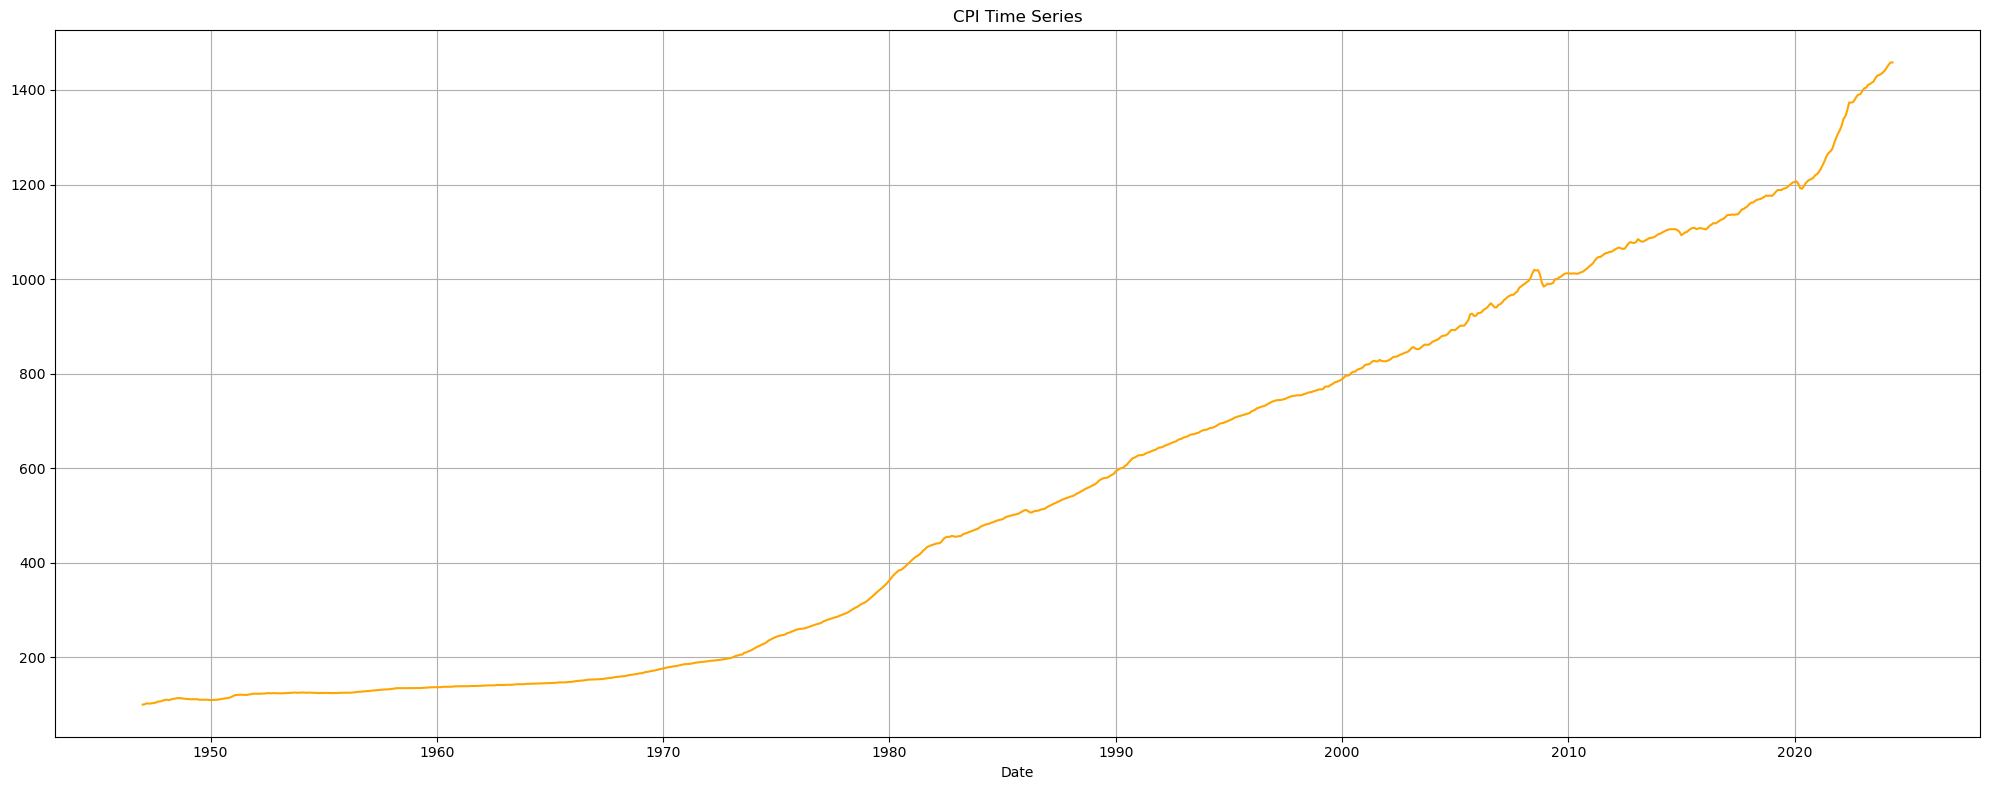

In [280]:

plt.figure(figsize=(20, 8))
plt.plot(cpi, color = "orange")
plt.title('CPI Time Series')
plt.xlabel('Date')
plt.grid(True)
plt.tight_layout()


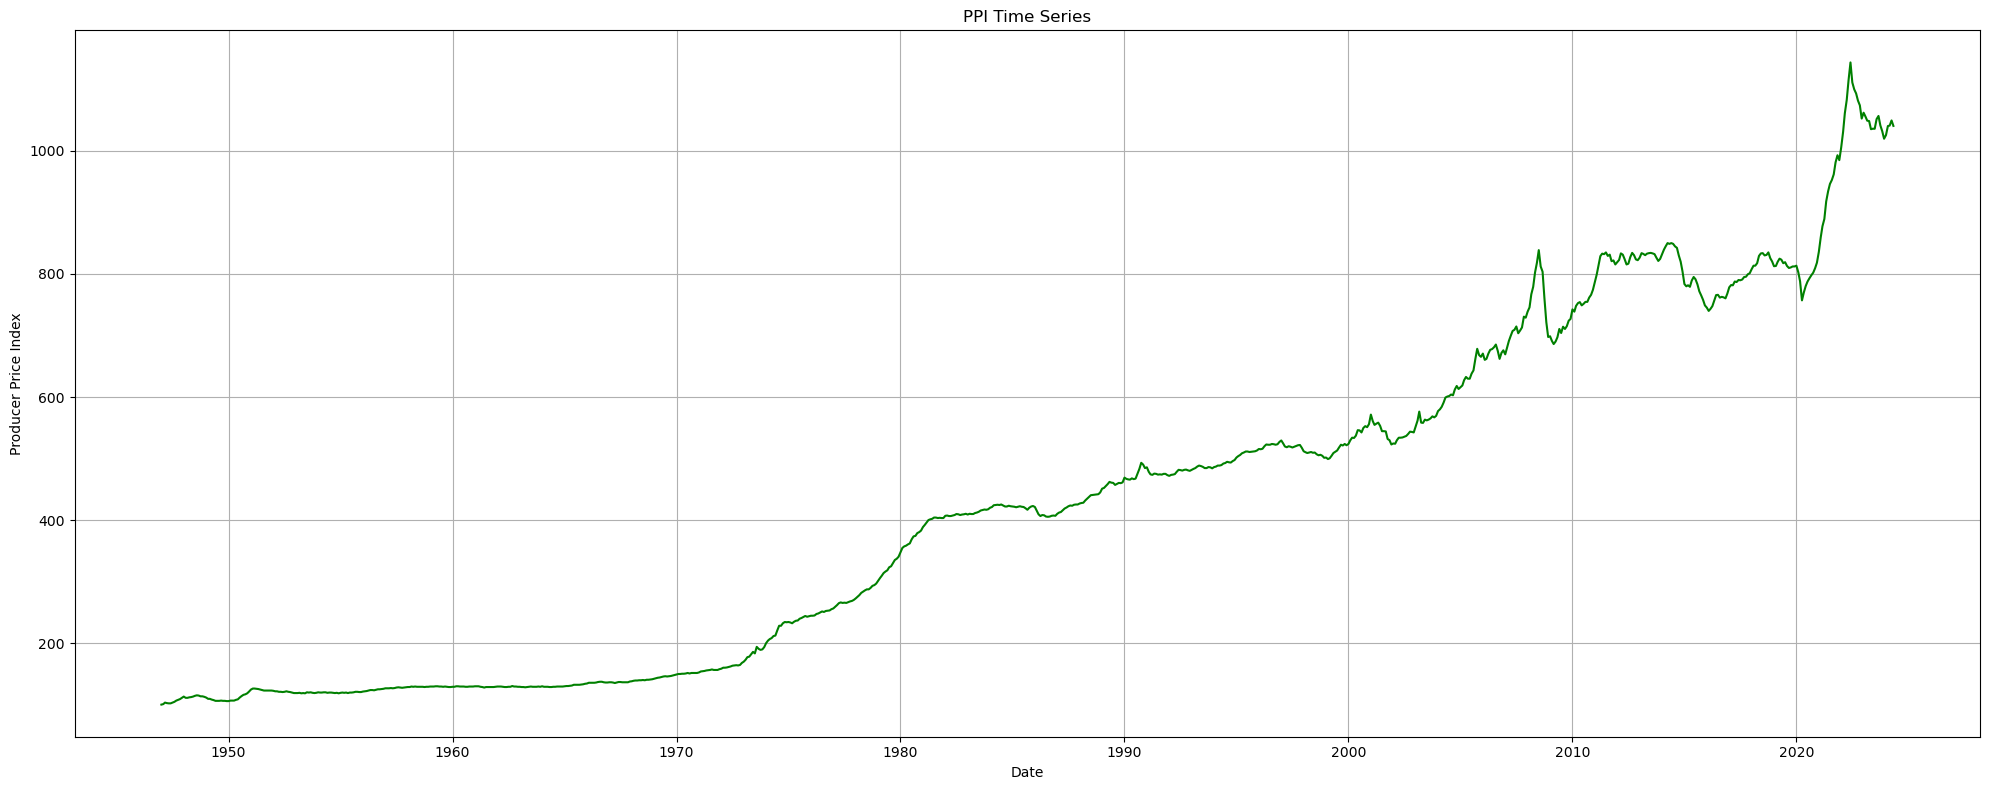

In [281]:
plt.figure(figsize=(20, 8))
plt.title('PPI Time Series')
plt.xlabel('Date')
plt.ylabel("Producer Price Index")
plt.plot(ppi, color="green")
plt.grid(True)
plt.tight_layout()

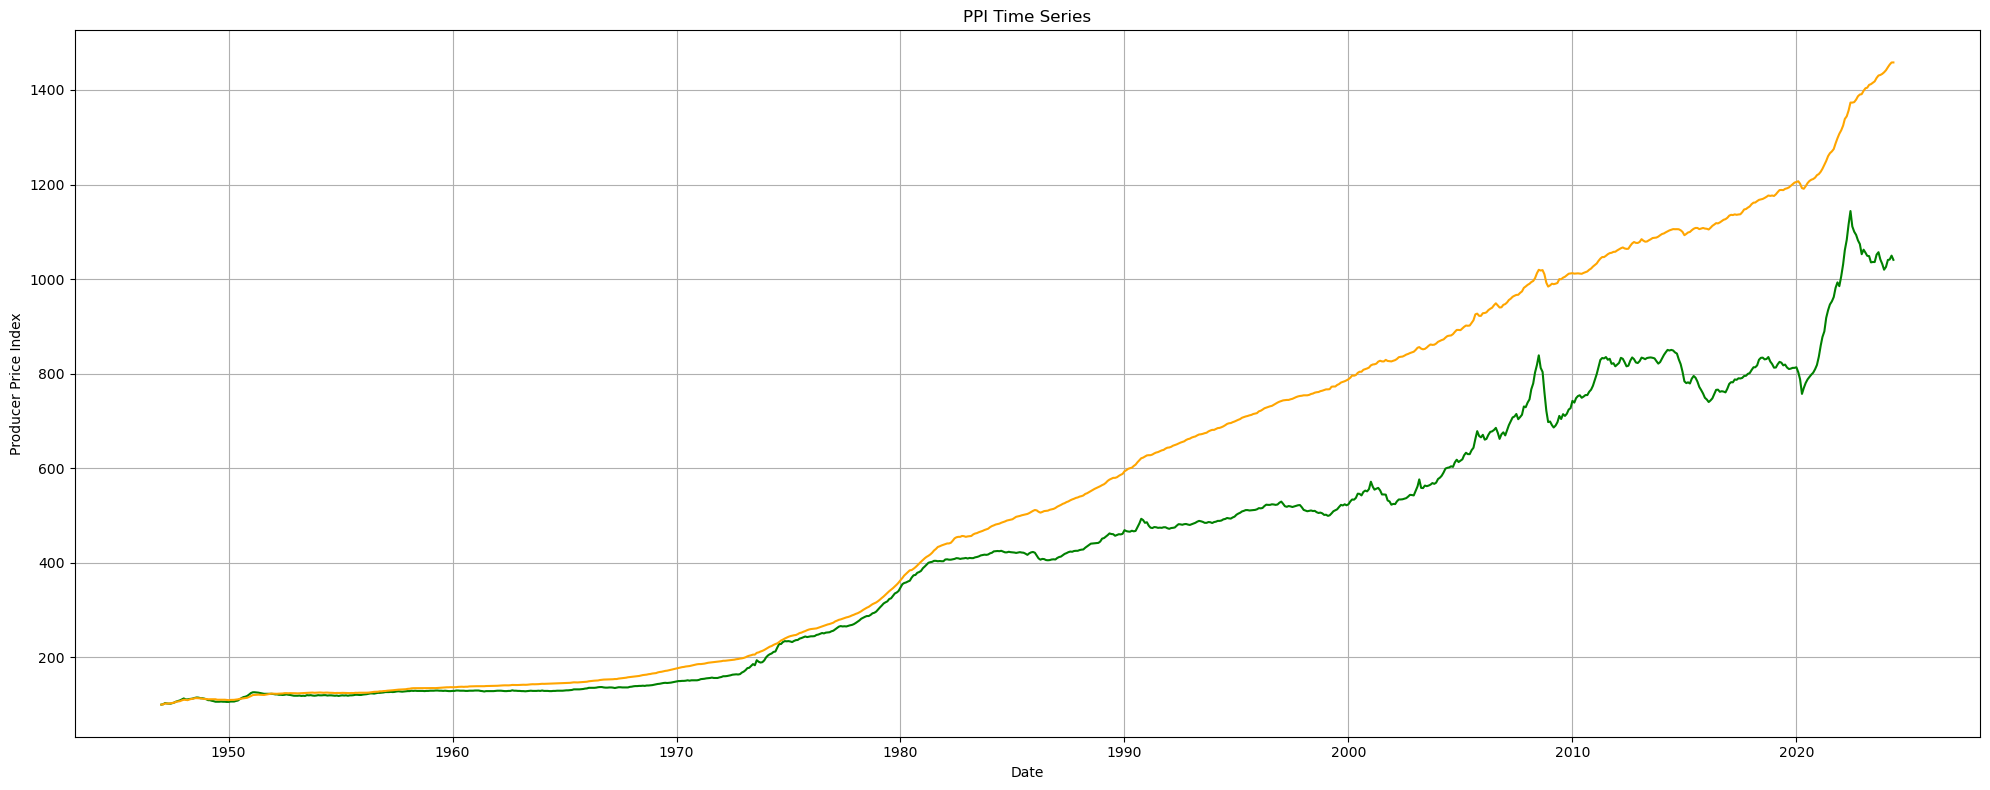

In [282]:
plt.figure(figsize=(20, 8))
plt.title('PPI Time Series')
plt.xlabel('Date')
plt.ylabel("Producer Price Index")
plt.plot(ppi, color="green")
plt.plot(cpi, color="orange")
plt.grid(True)
plt.tight_layout()

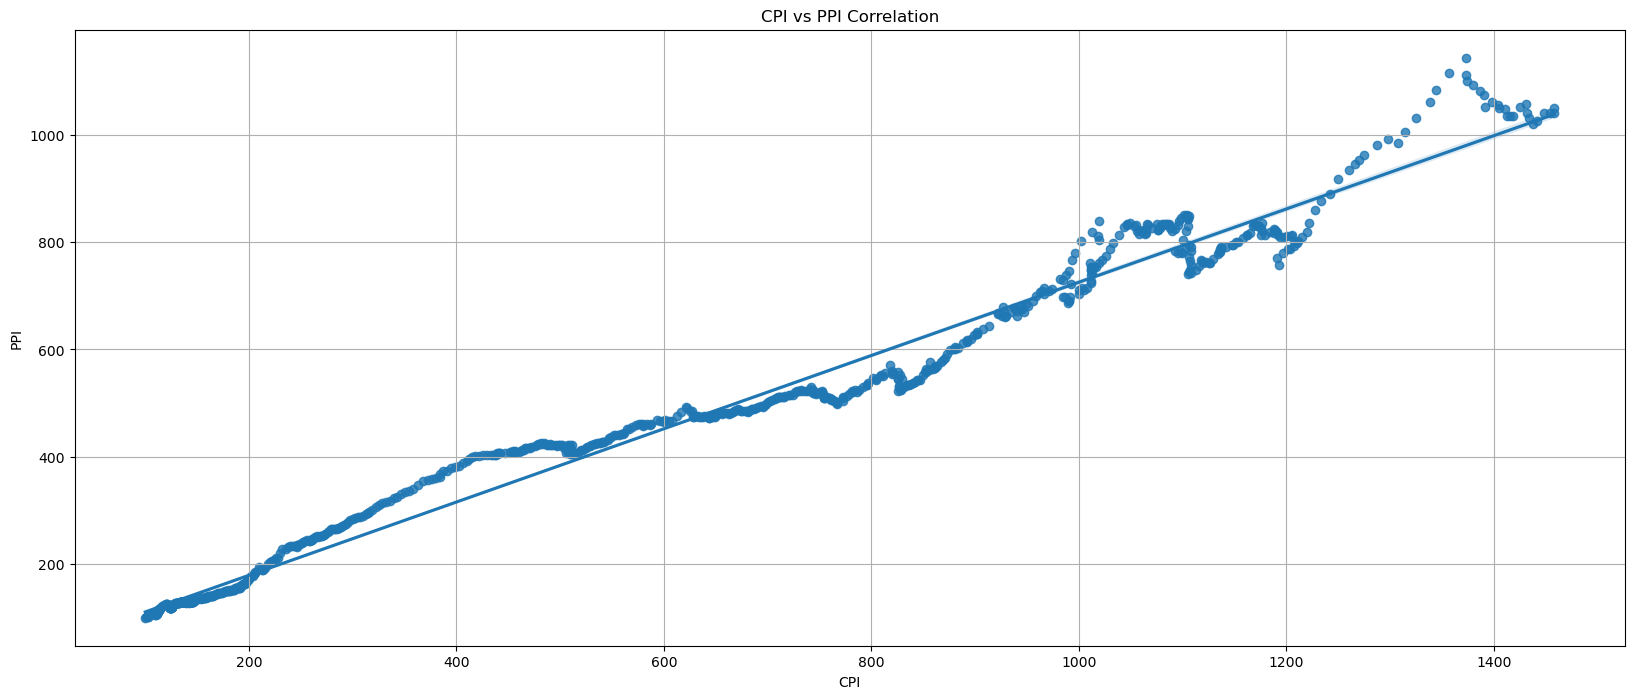

<Figure size 640x480 with 0 Axes>

In [283]:
plt.figure(figsize=(20, 8))
sns.regplot(data=df_mod, x='CPI', y='PPI')
plt.title('CPI vs PPI Correlation')
plt.grid(True)
plt.show()
plt.tight_layout()


In [284]:
cpi_ppi_cor = df_mod.corr()
cpi_ppi_cor


,CPI,PPI
CPI,1.000000,0.991457
PPI,0.991457,1.000000


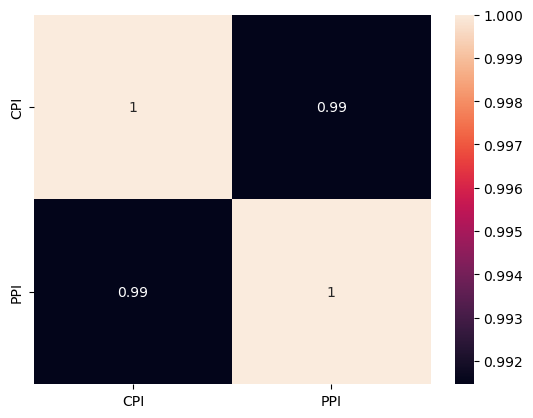

In [285]:
# drawing heatmap
sns.heatmap(cpi_ppi_cor, annot=True)
plt.show()

In [286]:
# find the CPI and PPI Rate
cpi_rate = cpi.pct_change().dropna()
ppi_rate = ppi.pct_change().dropna()

In [287]:
cpi_rate

Date
1947-02-01    0.006518
1947-03-01    0.017576
1947-04-01    0.000000
1947-05-01   -0.002273
1947-06-01    0.005923
                ...   
2024-01-01    0.003054
2024-02-01    0.004421
2024-03-01    0.003781
2024-04-01    0.003129
2024-05-01    0.000057
Name: CPI, Length: 928, dtype: float64

In [288]:
ppi_rate

Date
1947-02-01    0.008163
1947-03-01    0.024292
1947-04-01   -0.007905
1947-05-01   -0.003984
1947-06-01    0.000000
                ...   
2024-01-01    0.005763
2024-02-01    0.014357
2024-03-01    0.000792
2024-04-01    0.007985
2024-05-01   -0.008485
Name: PPI, Length: 928, dtype: float64

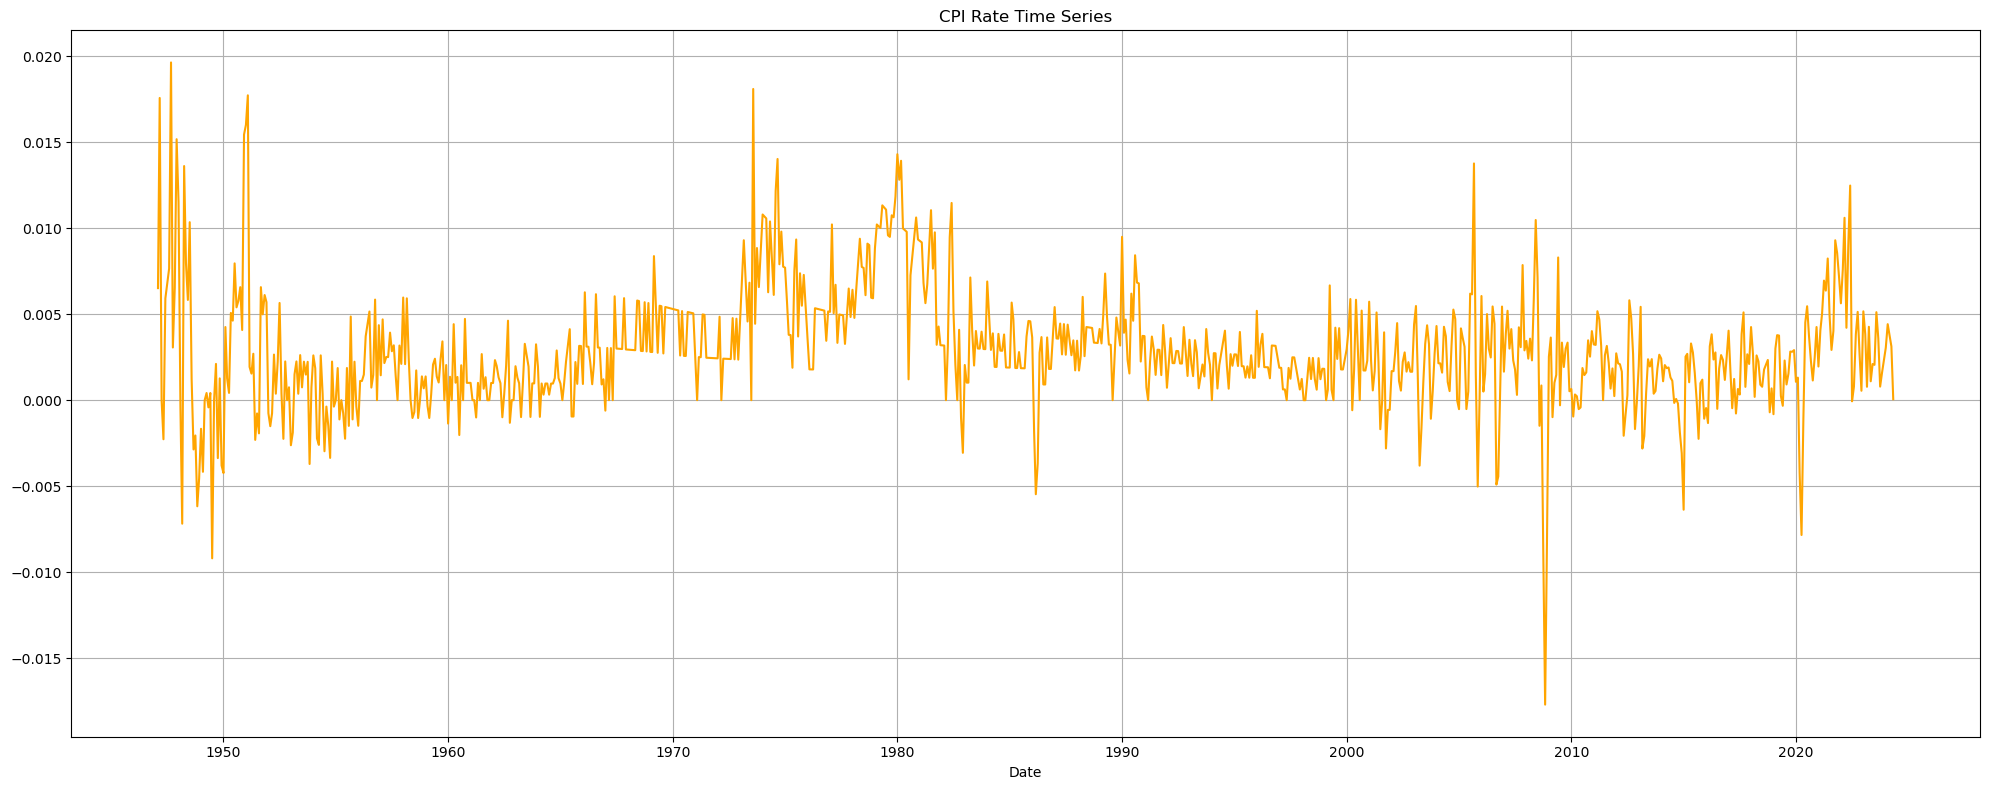

In [289]:
plt.figure(figsize=(20, 8))
plt.plot(cpi_rate, color='orange')
plt.title('CPI Rate Time Series')
plt.xlabel('Date')
plt.grid(True)
plt.tight_layout()
plt.show()

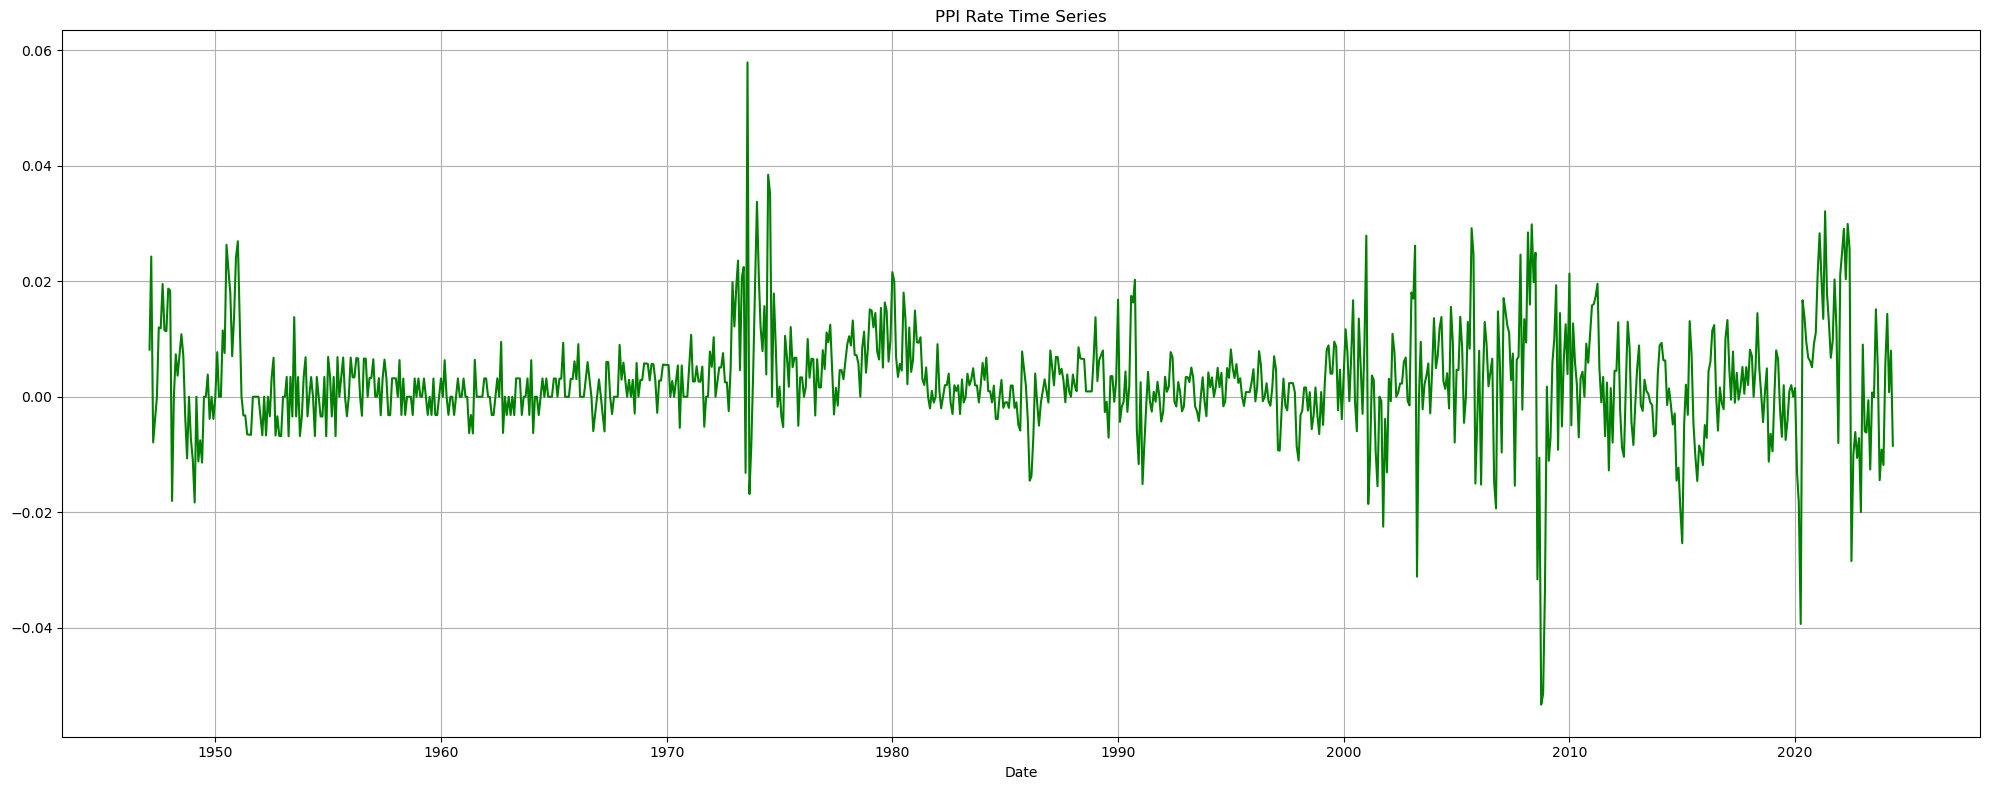

In [290]:
plt.figure(figsize=(20, 8))
plt.plot(ppi_rate, color='green')
plt.title('PPI Rate Time Series')
plt.xlabel('Date')
plt.grid(True)
plt.tight_layout()
plt.show()

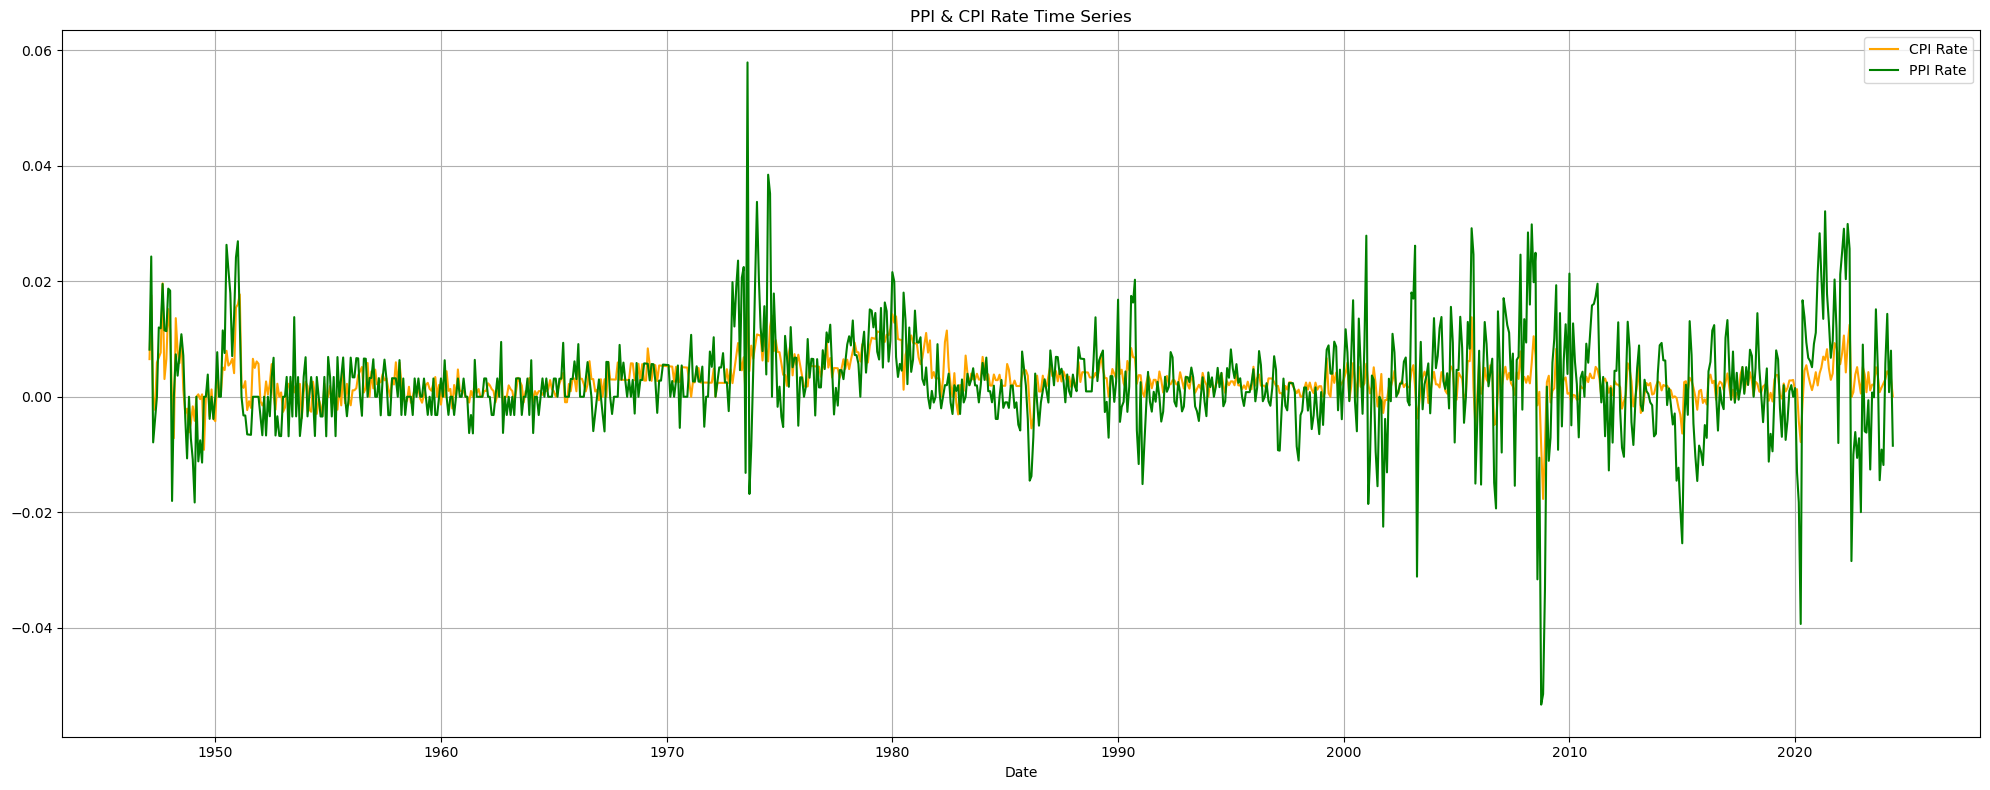

In [291]:
plt.figure(figsize=(20, 8))
plt.plot(cpi_rate, color='orange', label='CPI Rate')
plt.plot(ppi_rate, color='green', label='PPI Rate')
plt.title('PPI & CPI Rate Time Series')
plt.xlabel('Date')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [292]:
df_mod


,CPI,PPI
Date,,
1947-01-01,100.00000,100.00000
1947-02-01,100.65177,100.81633
1947-03-01,102.42086,103.26531
1947-04-01,102.42086,102.44898
1947-05-01,102.18808,102.04082
...,...,...
2024-01-01,1441.73650,1025.73878
2024-02-01,1448.10987,1040.46531
2024-03-01,1453.58473,1041.28980


In [293]:
df_mod

,CPI,PPI
Date,,
1947-01-01,100.00000,100.00000
1947-02-01,100.65177,100.81633
1947-03-01,102.42086,103.26531
1947-04-01,102.42086,102.44898
1947-05-01,102.18808,102.04082
...,...,...
2024-01-01,1441.73650,1025.73878
2024-02-01,1448.10987,1040.46531
2024-03-01,1453.58473,1041.28980


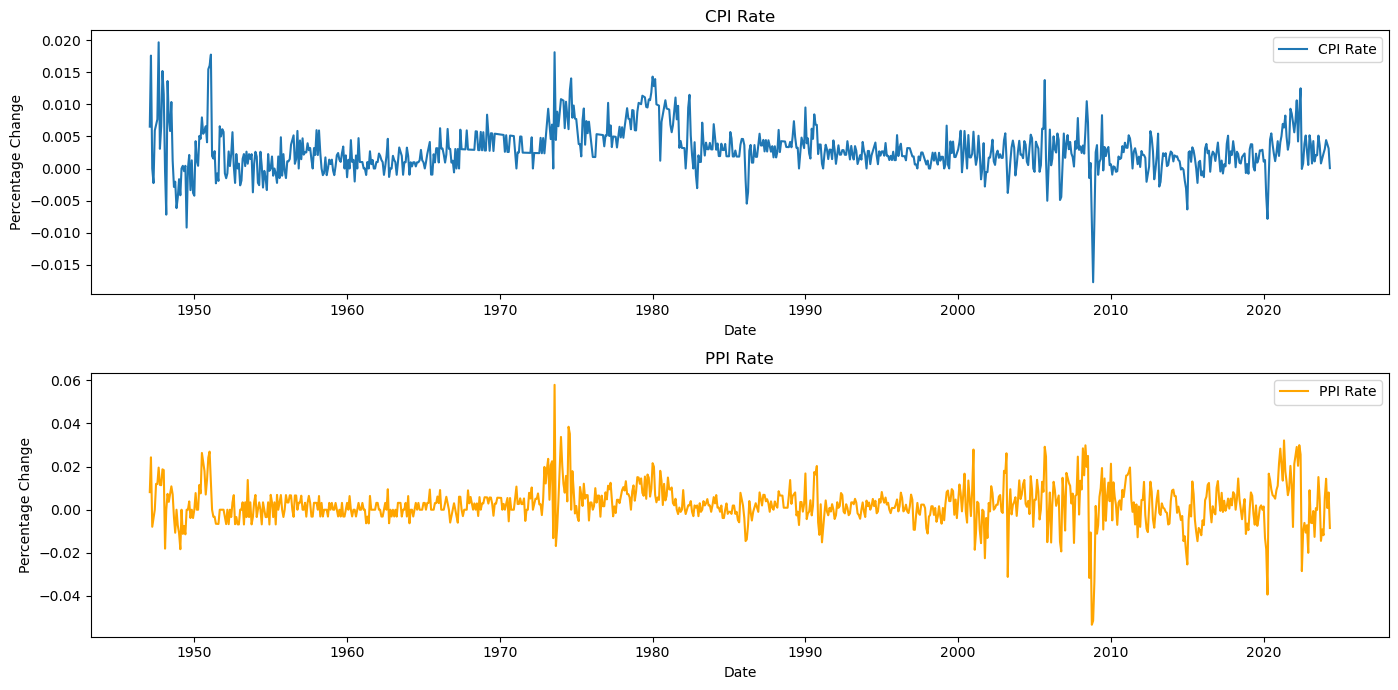

In [294]:
plt.figure(figsize=(14, 7))

plt.subplot(2, 1, 1)
plt.plot(cpi_rate, label='CPI Rate')
plt.title('CPI Rate')
plt.xlabel('Date')
plt.ylabel('Percentage Change')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(ppi_rate, label='PPI Rate', color='orange')
plt.title('PPI Rate')
plt.xlabel('Date')
plt.ylabel('Percentage Change')
plt.legend()

plt.tight_layout()
plt.show()


/Users/anbschool0012/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/anbschool0012/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/anbschool0012/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/anbschool0012/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/anbschool0012/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarn

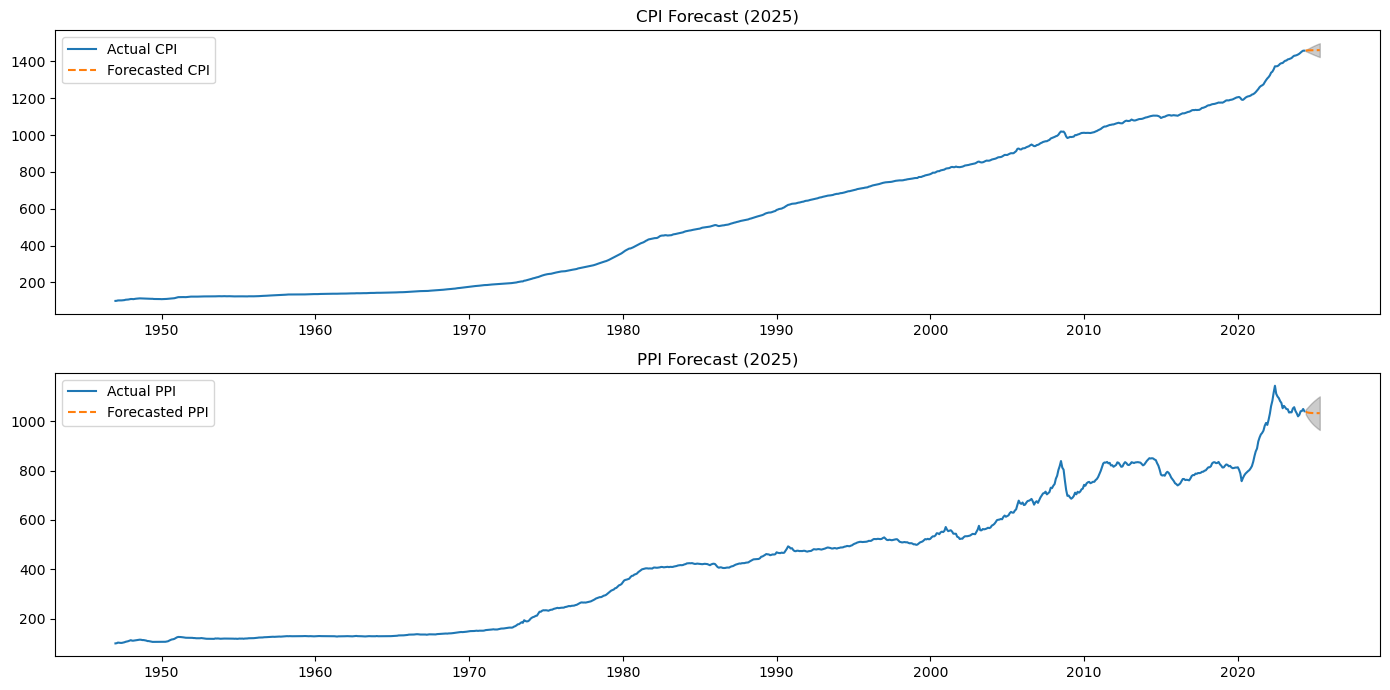

In [295]:
# ARIMA Model: We use ARIMA models to forecast CPI and PPI for the next 12 months.
from statsmodels.tsa.arima.model import ARIMA

# Determine the best ARIMA model for CPI
best_cfg_cpi = (1, 1, 1)  # Example order
# Fit ARIMA model for CPI
arima_model_cpi = ARIMA(df_mod['CPI'], order=best_cfg_cpi)
arima_result_cpi = arima_model_cpi.fit()

# Forecast the next 12 months for CPI
forecast_cpi = arima_result_cpi.get_forecast(steps=12)
forecast_cpi_df = forecast_cpi.conf_int()
forecast_cpi_df['Forecast'] = forecast_cpi.predicted_mean

# Determine the best ARIMA model for PPI
best_cfg_ppi = (1, 1, 1)  # Example order
# Fit ARIMA model for PPI
arima_model_ppi = ARIMA(df_mod['PPI'], order=best_cfg_ppi)
arima_result_ppi = arima_model_ppi.fit()

# Forecast the next 12 months for PPI
forecast_ppi = arima_result_ppi.get_forecast(steps=12)
forecast_ppi_df = forecast_ppi.conf_int()
forecast_ppi_df['Forecast'] = forecast_ppi.predicted_mean

# Plot the forecasts
plt.figure(figsize=(14, 7))
# CPI Forecast
plt.subplot(2, 1, 1)
plt.plot(df_mod['CPI'], label='Actual CPI')
plt.plot(forecast_cpi_df['Forecast'], label='Forecasted CPI', linestyle='--')
plt.fill_between(forecast_cpi_df.index,
                 forecast_cpi_df.iloc[:, 0],
                 forecast_cpi_df.iloc[:, 1], color='k', alpha=0.2)
plt.title('CPI Forecast (2025)')
plt.legend()
# PPI Forecast
plt.subplot(2, 1, 2)
plt.plot(df_mod['PPI'], label='Actual PPI')
plt.plot(forecast_ppi_df['Forecast'], label='Forecasted PPI', linestyle='--')
plt.fill_between(forecast_ppi_df.index,
                 forecast_ppi_df.iloc[:, 0],
                 forecast_ppi_df.iloc[:, 1], color='k', alpha=0.2)
plt.title('PPI Forecast (2025)')
plt.legend()
plt.tight_layout()
plt.show()
